In [1]:
import sys
import os

os.chdir('../')
os.getcwd()

'/Users/lbrice1/repos/ai_cheme_examples'

# Import packages

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from pacmap import pacmap

import matplotlib.pyplot as plt
from matplotlib import ticker

import simpsom.hexagons as hx
from mpl_toolkits.axes_grid1 import make_axes_locatable
import random
from matplotlib import cm


OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


# Load data

In [3]:
data_tep = pd.read_excel('data/TEP_selected_faults_0_1_4.xlsx', index_col=0).dropna().sample(100)
X = data_tep.iloc[:, :-1]
y = data_tep.iloc[:, -1]

In [4]:
data_tep.describe()

,VA1,VA2,VA3,VA4,VA5,VA6,VA7,VA8,VA9,VA10,...,VA42,VA43,VA44,VA45,VA46,VA47,VA48,VA49,VA50,label
count,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,...,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.00000
mean,0.460455,3657.336871,4438.626731,9.045407,32.304518,47.506467,2798.890088,64.948910,122.899347,0.211439,...,62.940399,53.108997,45.284170,59.260482,25.985151,37.191672,46.423179,36.970686,12.677805,1.83000
std,0.254548,17.920221,30.067751,0.270425,0.448833,0.473296,5.802994,0.491606,0.012987,0.058405,...,0.124338,0.194481,25.045674,1.715543,7.672656,0.275999,0.090122,1.435100,1.658966,1.68208
min,0.249619,3597.650893,4368.677793,8.390435,30.075084,45.080391,2765.183690,63.543321,122.867249,0.001455,...,62.584812,52.598564,24.737133,55.377923,0.388948,36.567840,46.125803,34.976566,7.516140,0.00000
25%,0.264757,3648.236544,4419.050347,8.764122,32.215843,47.408344,2799.206798,64.590981,122.889536,0.202865,...,62.861180,53.021611,26.081279,57.267135,24.901150,37.145236,46.401444,35.897108,11.831179,0.75000
50%,0.274930,3656.887010,4436.174384,9.196885,32.397963,47.561812,2799.923674,64.993393,122.900320,0.209531,...,62.928726,53.096416,26.919548,60.481535,25.661270,37.195480,46.426448,36.025402,12.742056,1.00000
75%,0.763504,3667.798305,4458.106632,9.265672,32.494266,47.773251,2800.632399,65.261519,122.908970,0.218026,...,63.010761,53.181397,75.209979,60.592048,26.766798,37.219528,46.446651,38.785473,13.797942,4.00000
max,1.018611,3704.205961,4557.157198,9.370167,33.050021,48.387469,2803.990079,66.092903,122.928305,0.557730,...,63.316327,54.006834,100.000000,60.751098,72.681780,38.595263,46.883085,39.140003,17.280068,4.00000


# Data processing

In [5]:
X_train, X_test, y_train, y_test = train_test_split(X,
                                                    y,
                                                    test_size=0.2,
                                                    shuffle=True,
                                                    random_state=0)

trainset = np.column_stack((X_train, y_train))
testset = np.column_stack((X_test, y_test))

scaler = MinMaxScaler()

scaler.fit(X_train)

X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Do dimensionality reduction

## PCA

In [6]:
def pca_reduce(X, n_components=2):
    """
    Reduce the dimensionality of the data using PCA.
    :param X: The data to be reduced.
    :param n_components: The number of components to reduce to.
    :return: The fitted PCA model and the reduced data.
    """
    pca_model = PCA(n_components=n_components)
    X_reduced = pca_model.fit_transform(X)
    return pca_model, X_reduced

pca_model, X_train_reduced = pca_reduce(X_train_scaled, n_components=2)
X_test_reduced = pca_model.transform(X_test_scaled)

data_train = pd.DataFrame(X_train_reduced, index = X_train.index)
data_train = pd.concat([data_train, y_train], axis=1)

# Do Self-Organizing MAP

In [8]:
import simpsom as sps

net = sps.SOMNet(
    20, 
    20, 
    data_tep, 
    random_seed=123
)

net.train(
    train_algo='batch',
    start_learning_rate=0.1, 
    epochs=-1, 
    batch_size=1,
)

Periodic Boundary Conditions inactive.
The weights will be initialized with PCA.
The map will be trained with the batch algorithm.
Training SOM... done!


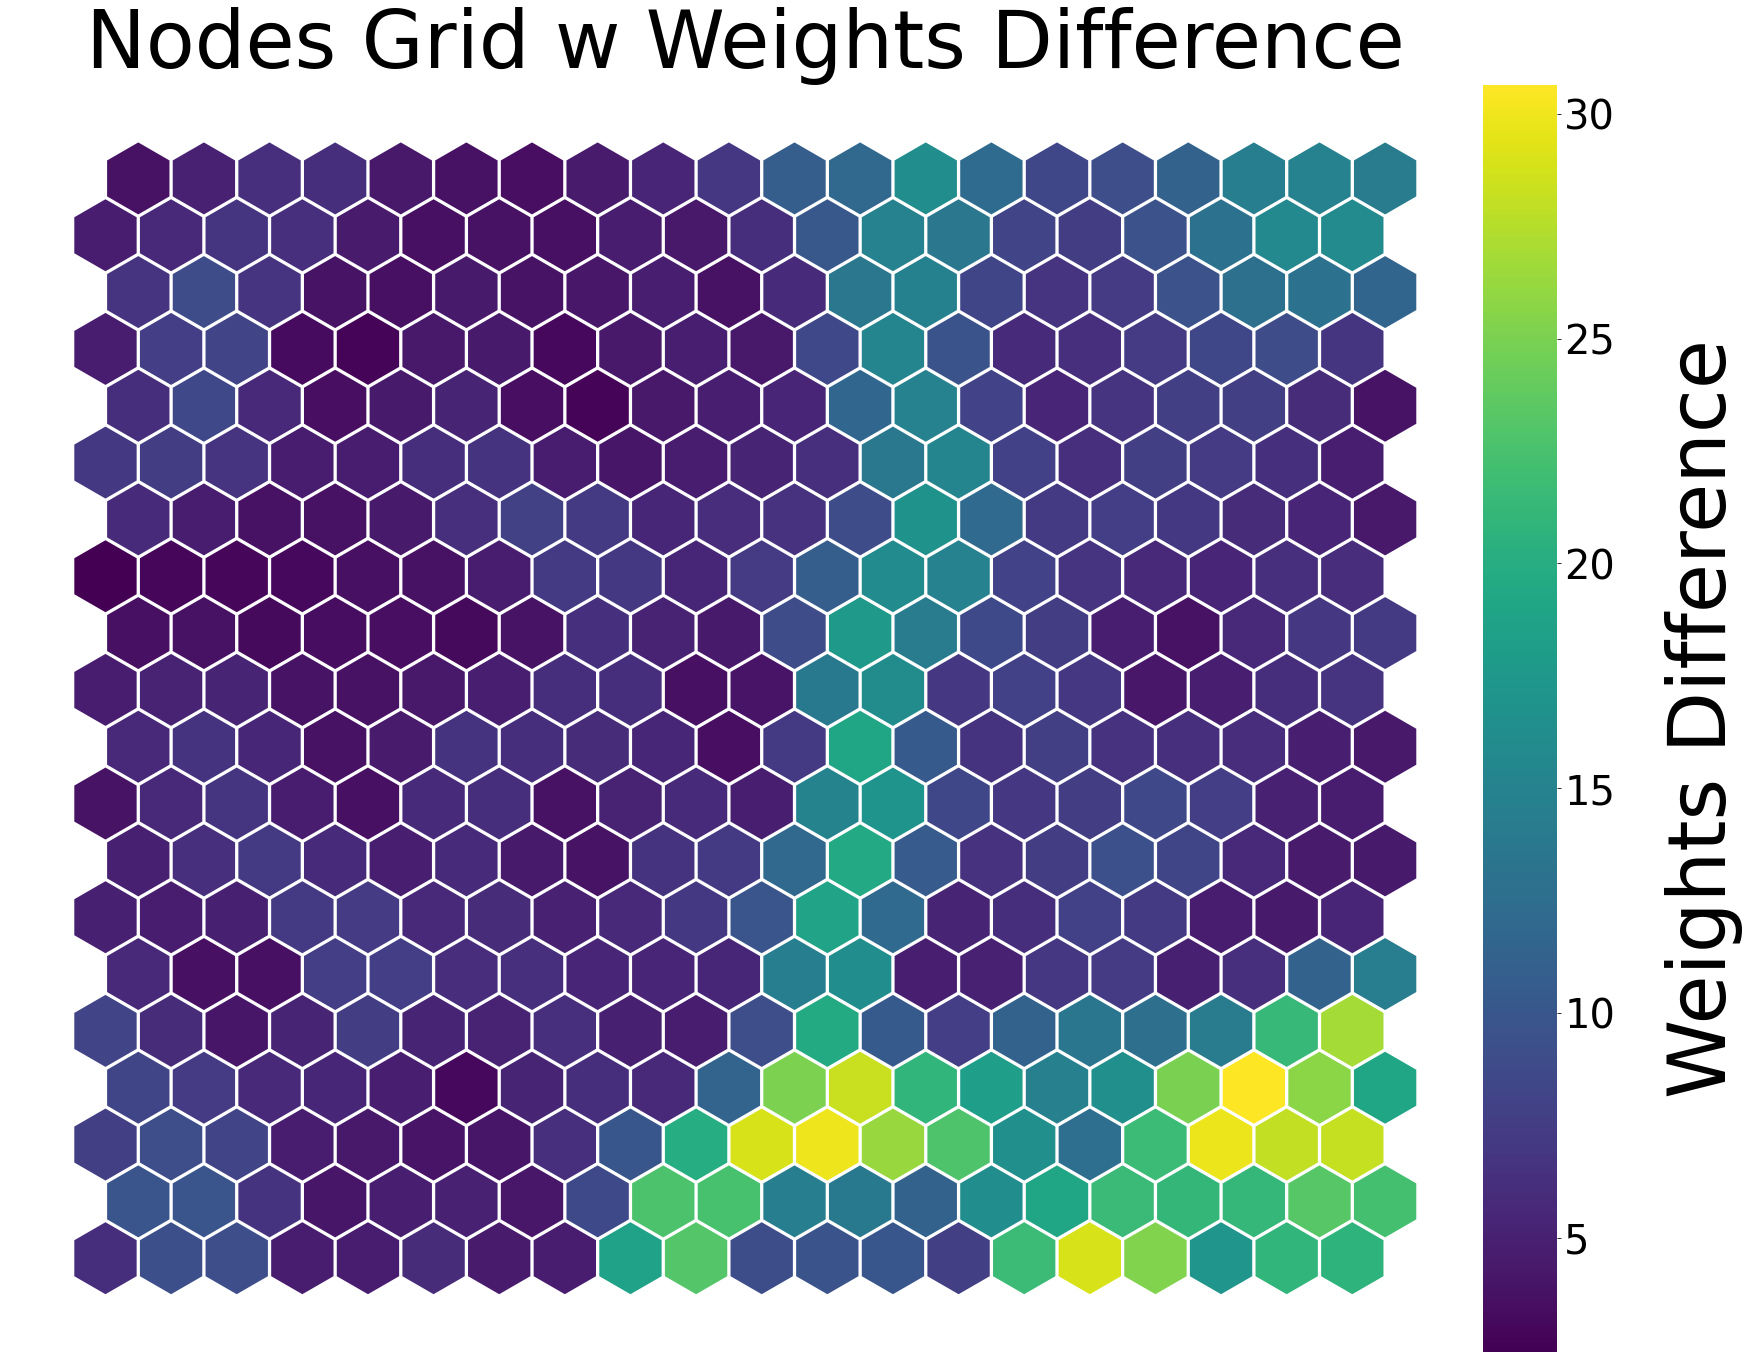

<Figure size 640x480 with 0 Axes>

In [15]:
diffs = net.diff_graph(show=True, returns = True)

In [30]:
idx = data_train.index
bmu_list = net.project(data_tep.loc[idx, :], colnum = -1, show = False)

/Users/lbrice1/venvs/aicheme/lib/python3.11/site-packages/simpsom/network.py:629: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter([pos[0]-0.125+random.random()*0.25 for pos in bmu_list],


<Figure size 640x480 with 0 Axes>

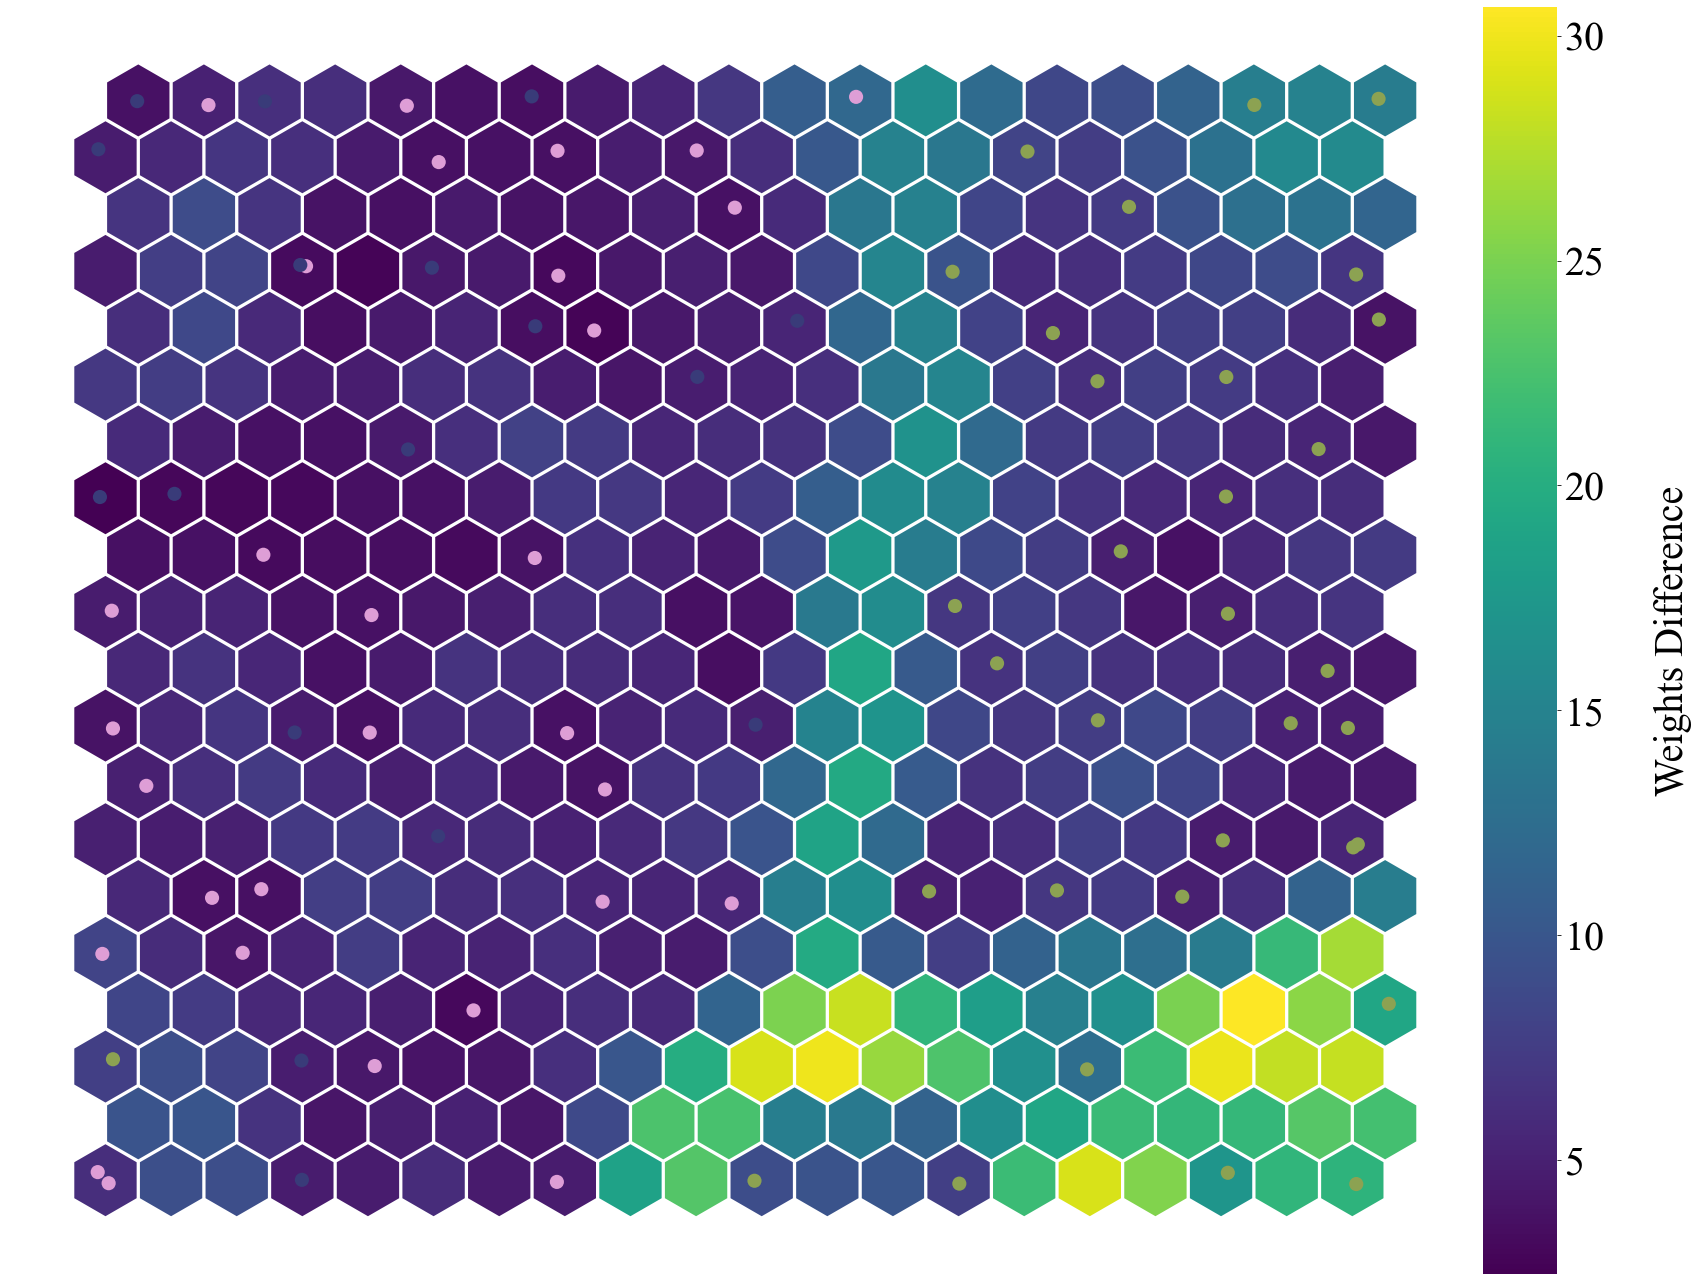

In [ ]:
side    = np.sqrt(net.net_width*net.net_height)
width_p = 100
dpi     = 72
x_inch  = net.net_width*width_p/dpi 
y_inch  = net.net_height*width_p/dpi 
fig     = plt.figure(figsize=(x_inch, y_inch), dpi=dpi)

centers = [[node.pos[0],node.pos[1]] for node in net.node_list]

ax = hx.plot_hex(fig, centers, diffs)

plt.scatter(
    [pos[0]-0.125+random.random()*0.25 for pos in bmu_list],
    [pos[1]-0.125+random.random()*0.25 for pos in bmu_list],  
    c = data_train.iloc[:, -1],
    cmap=cm.tab20b,
    s=200, linewidth=0, zorder=10)

divider = make_axes_locatable(ax)
cax     = divider.append_axes("right", size="5%", pad=0.0)
cbar    = plt.colorbar(ax.collections[0], cax=cax, shrink = 0.5)
cbar.set_label('Weights Difference', size=2*side, labelpad=2.5*side)
cbar.ax.tick_params(labelsize=2*side)
cbar.outline.set_visible(False)

plt.rcParams['mathtext.fontset'] = 'cm'
plt.rcParams["font.family"] = "serif"
plt.rcParams["font.serif"] = ["Times New Roman"
                                ] + plt.rcParams["font.serif"]
plt.rcParams['font.size']=15
plt.rcParams['axes.linewidth'] = 1 
plt.sca(ax)

plt.savefig('figures/example-4-2.png', dpi=300, bbox_inches='tight')
plt.show()

